In [ ]:
!pip install ultralytics supervision opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 5.8 MB/s eta 0:00:00


In [ ]:

from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

from google.colab import files
uploaded = files.upload()

Saving Basketball.mp4 to Basketball.mp4
Saving Cricket.mp4 to Cricket.mp4
Saving Football.mp4 to Football.mp4
Saving Netball.mp4 to Netball.mp4
Saving Relay.mp4 to Relay.mp4


In [ ]:
video_path = list(uploaded.keys())[2]

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

In [ ]:
video_info = sv.VideoInfo.from_video_path(video_path)
print(video_info)

VideoInfo(width=720, height=966, fps=30.0, total_frames=300)


In [ ]:

output_path = "tracked_output.mp4"
sink = sv.VideoSink(output_path, video_info)
sink.__enter__()

In [ ]:
frame_generator = sv.get_video_frames_generator(video_path)
for frame in frame_generator:
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    detections = tracker.update_with_detections(detections)
    labels = [
        f"Player {tracker_id}"
        for tracker_id in detections.tracker_id
    ]
    annotated = box_annotator.annotate(
        scene=frame,
        detections=detections
    )
    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )
    sink.write_frame(annotated)
sink.__exit__(None, None, None)
print("Finished")

Finished


In [ ]:
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pose_model = YOLO("yolov8n-pose.pt")

In [ ]:
results = pose_model(frame)[0]


0: 640x480 1 person, 143.6ms
Speed: 2.9ms preprocess, 143.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)



0: 640x480 2 persons, 146.8ms
Speed: 3.4ms preprocess, 146.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)


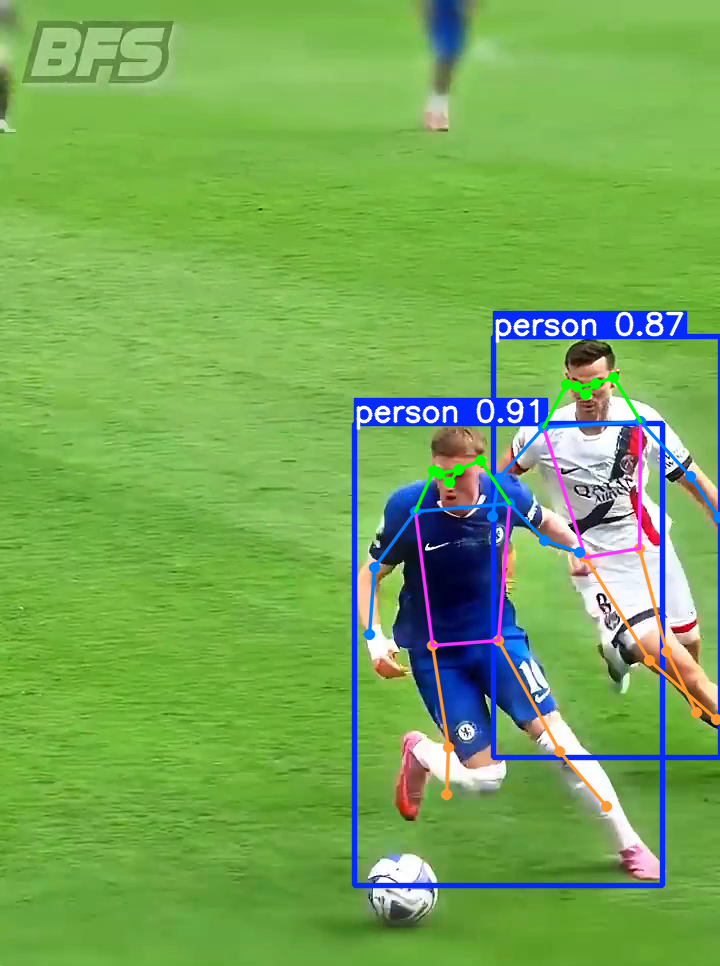

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    results = pose_model(frame)
    annotated_frame = results[0].plot()
    cv2_imshow(annotated_frame)
cap.release()

In [ ]:
results = pose_model.predict(
    source=video_path,
    save=True,
    conf=0.3
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/300) /content/Football.mp4: 640x480 2 persons, 125.3ms
video 1/1 (frame 2/300) /content/Football.mp4: 640x480 2 persons, 134.5ms
video 1/1 (frame 3/300) /content/Football.mp4: 640x480 2 persons, 127.7ms
video 1/1 (frame 4/300) /content/Football.mp4: 640x480 2 persons, 122.3ms
video 1/1 (frame 5/300) /content/Football.mp4: 640x480 3 persons, 146.9ms
video 1/1 (frame 6/300) /content/Football.mp4: 640x480 3 persons, 138.7ms
video 1/1 (fra

In [ ]:
from google.colab import files

files.download("runs/pose/predict/Football.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# =====================================================================
# 1. VALIDATE DETECTOR (yolov8n.pt)
# =====================================================================
print("--- Validating Player Detection Model ---")
det_model = YOLO("yolov8n.pt")

# Runs validation on the benchmark COCO8 dataset
det_metrics = det_model.val(data="coco8.yaml", plots=True)

print("\n[DETECTION METRICS SUMMARY]")
print(f"Box Precision (P)    : {det_metrics.box.mp:.4f}")
print(f"Box Recall (R)       : {det_metrics.box.mr:.4f}")
print(f"Box mAP @ 50         : {det_metrics.box.map50:.4f}")
print(f"Box mAP @ 50-95      : {det_metrics.box.map:.4f}")


# =====================================================================
# 2. VALIDATE POSE ESTIMATOR (yolov8n-pose.pt)
# =====================================================================
print("\n--- Validating Keypoint/Pose Model ---")
pose_model = YOLO("yolov8n-pose.pt")

# Runs validation on the benchmark COCO8-Pose dataset
pose_metrics = pose_model.val(data="coco8-pose.yaml", plots=True)

print("\n[POSE METRICS SUMMARY]")
print(f"Pose Precision (P)   : {pose_metrics.pose.mp:.4f}")
print(f"Pose Recall (R)      : {pose_metrics.pose.mr:.4f}")
print(f"Pose mAP @ 50        : {pose_metrics.pose.map50:.4f}")
print(f"Pose mAP @ 50-95     : {pose_metrics.pose.map:.4f}")


# =====================================================================
# 3. LOCATE YOUR PLOTS & CURVES FOR THE REPORT
# =====================================================================
print("\n--- Validation Run Directories ---")
print(f"Detection plots saved in: {det_metrics.save_dir}")
print(f"Pose plots saved in:      {pose_metrics.save_dir}")

--- Validating Player Detection Model ---
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 3.5Kfiles/s 0.0s
Dataset download success ✅ (0.3s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1563.8±846.0 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.9Kit/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          4         17      0.621      0.833      0.888      0.629
                person          3         